In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.community_detection import CommunityDetection
from src.ansatze import Ansatz
from src.simulator import QuimbSimulator
from src.optimizer import COBYLA
from src.lvqe import LayerVQE
from quantum_walk.community_detection_qw import detect_communities, modularity, top_k_degree_vertices, visualize_communities


ModuleNotFoundError: No module named 'src'

In [2]:
G = nx.Graph()
G.add_edges_from([
    # community A: nodes 0-4
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (0, 2), (1, 3),
    # community B: nodes 5-9
    (5, 6), (6, 7), (7, 8), (8, 9), (9, 5), (5, 7), (6, 8),
    # one bridge
    (4, 5),
])
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 10 nodes, 15 edges


In [3]:
k = 2
problem = CommunityDetection(G, k)

sim = QuimbSimulator()
lvqe = LayerVQE(problem=problem, simulator=sim, optimizer_class=COBYLA, n_layers=2,
    k_per_layer=100, k_final=500, use_sampling=False)

result_lvqe = lvqe.run()

Starting L-VQE: 2 layers, 100 iter/layer, 500 final iter
Mode: exact expectation

Layer 0: 



COBYLA: 100%|██████████| 100/100 [00:03<00:00, 28.74it/s, best_E=-0.4333]


Total evaluations: 100
layer 0: energy=-0.4333, approx_ratio=+1.0000

Layer 1 — 100 iterations (before convergence)


COBYLA: 100%|██████████| 100/100 [00:05<00:00, 19.49it/s, best_E=-0.4333]


Total evaluations: 100
layer 1: energy=-0.4333, approx_ratio=+1.0000

Final layer — 500 iterations (final)


COBYLA: 100%|██████████| 500/500 [00:31<00:00, 16.11it/s, best_E=-0.4333]


Total evaluations: 500
layer 2: energy=-0.4333, approx_ratio=+1.0000


In [4]:
from itertools import product


def to_communities(assignment):
    groups = {}
    for node, label in enumerate(assignment):
        groups.setdefault(label, []).append(node)
    return groups


def is_equivalent_k2(a, b):
    # For k=2, assignments are equivalent up to global label flip.
    return a == b or all((1 - x) == y for x, y in zip(a, b))


# 1) LVQE decoded assignments (from final circuit state)
bitstrings = sim.get_most_frequent_assignments(
    result_lvqe['final_params'], result_lvqe['final_ansatz'], problem=problem
)

best_assignment, best_proba = bitstrings[0]
modularity_lvqe = problem.evaluate(best_assignment)
communities_lvqe = to_communities(best_assignment)

print("LVQE decoded communities (most probable sample):")
for label, nodes in sorted(communities_lvqe.items()):
    print(f"  Community {label}: {nodes}")
print(f"LVQE decoded modularity Q = {modularity_lvqe:.4f} (probability: {best_proba:.3f}%)")
print(f"LVQE final energy/objective = {result_lvqe['final_energy']:.4f}")
print(f"Best-known objective value  = {problem.best_known_value:.4f}")


# 2) True optimum partition using CommunityDetection.evaluate (brute force)
best_q = -1e9
best_assignment_exact = None
for assignment in product(range(problem.k), repeat=problem.num_nodes):
    q = problem.evaluate(list(assignment))
    if q > best_q:
        best_q = q
        best_assignment_exact = list(assignment)

communities_exact = to_communities(best_assignment_exact)
print("\nExact best communities from evaluate():")
for label, nodes in sorted(communities_exact.items()):
    print(f"  Community {label}: {nodes}")
print(f"Exact best modularity Q = {best_q:.4f}")

if problem.k == 2:
    print(f"Equivalent to exact optimum (up to label swap): {is_equivalent_k2(best_assignment, best_assignment_exact)}")


LVQE decoded communities (most probable sample):
  Community 0: [5, 6, 7, 8, 9]
  Community 1: [0, 1, 2, 3, 4]
LVQE decoded modularity Q = 0.4333 (probability: 100.000%)
LVQE final energy/objective = -0.4333
Best-known objective value  = -0.4333

Exact best communities from evaluate():
  Community 0: [0, 1, 2, 3, 4]
  Community 1: [5, 6, 7, 8, 9]
Exact best modularity Q = 0.4333
Equivalent to exact optimum (up to label swap): True


/tmp/ipykernel_34517/4150664926.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max(n_colors, 2))


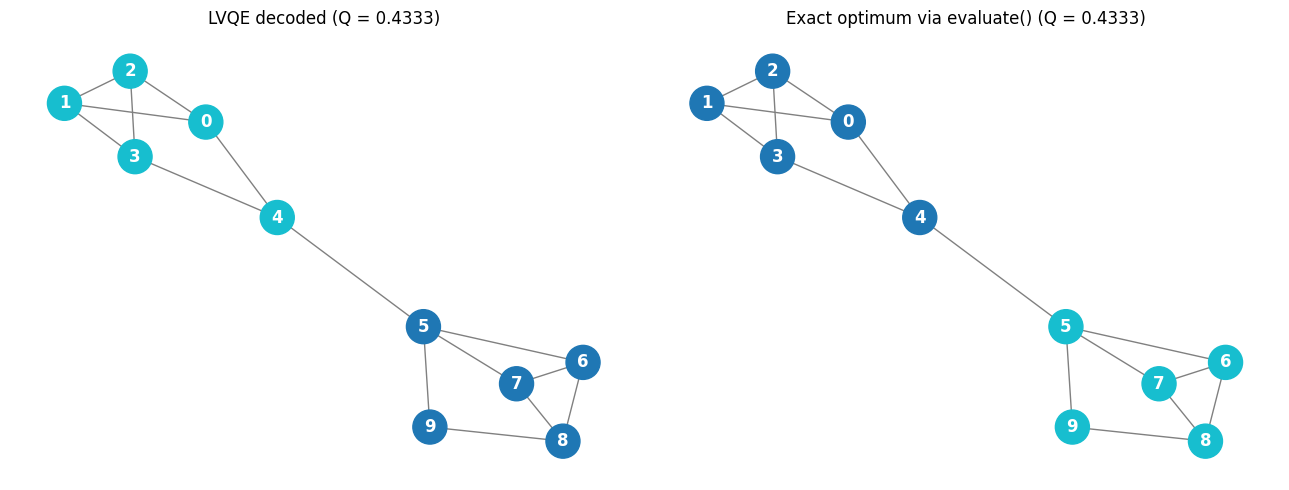

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm


def draw_partition(ax, assignment, title):
    pos = nx.spring_layout(G, seed=42)
    n_colors = max(assignment) + 1
    cmap = cm.get_cmap("tab10", max(n_colors, 2))
    node_colors = [cmap(assignment[node]) for node in G.nodes()]

    nx.draw_networkx(
        G,
        pos=pos,
        node_color=node_colors,
        with_labels=True,
        node_size=600,
        font_color="white",
        font_weight="bold",
        edge_color="gray",
        ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

draw_partition(
    axes[0],
    best_assignment,
    f"LVQE decoded (Q = {modularity_lvqe:.4f})",
)

draw_partition(
    axes[1],
    best_assignment_exact,
    f"Exact optimum via evaluate() (Q = {best_q:.4f})",
)

plt.tight_layout()
plt.show()


In [6]:
V_max = top_k_degree_vertices(G, k)
print(f"V_max (highest-degree nodes): {V_max}")

result_qw = detect_communities(
    G, V_max,
    q=None,         
    epsilon=1e-4,
    max_steps=2000,
    min_steps=50,
    refine=True,
    verbose=False
)

qw_communities = result_qw['communities']
qw_modularity = modularity(G, qw_communities)


print(f"QW converged: {result_qw['converged']} in {result_qw['steps_run']} steps")
print(f"QW communities found: {len(qw_communities)}")
for rep, members in qw_communities.items():
    print(f"  community {rep}: {members}")
print(f"QW modularity: {qw_modularity:.4f}")

V_max (highest-degree nodes): [5, 0]
QW converged: True in 749 steps
QW communities found: 2
  community 5: [5, 6, 7, 8, 9]
  community 4: [0, 1, 2, 3, 4]
QW modularity: 0.4333


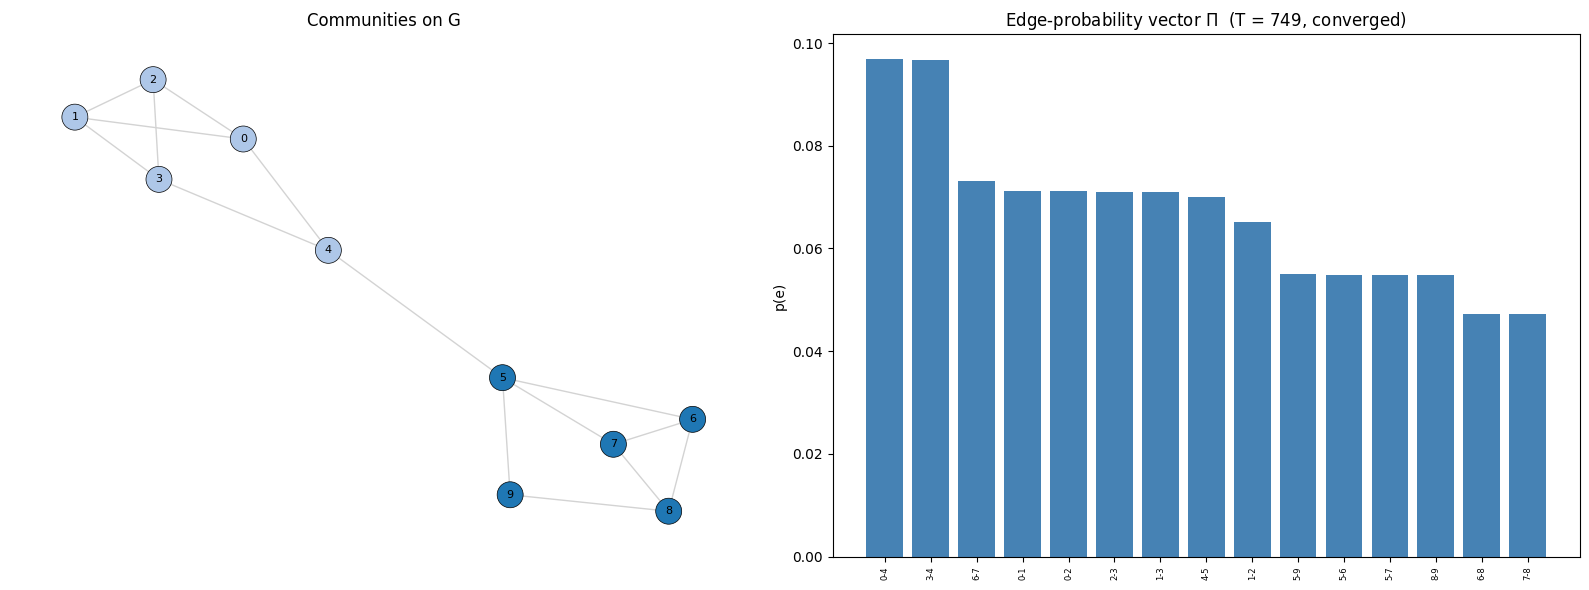

In [7]:
from quantum_walk.community_detection_qw import visualize_communities

visualize_communities(G, result_qw)
